### End to End deeplearning projec using simple rnn

In [1]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing import sequence
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense

In [2]:
# Load the IMDB dataset
max_features = 10000  # Number of words to consider as features
maxlen = 500  # Cut texts after this number of words (among top max_features most common words)
(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=max_features) 
print(f'{len(x_train)} training sequences')
print(f'{len(x_test)} testing sequences')

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
25000 training sequences
25000 testing sequences


In [4]:
print(f'x_test : {x_test.shape} | x_train : {x_train.shape}')
print(f'y_test : {y_test.shape} | y_train : {y_train.shape}')

x_test : (25000,) | x_train : (25000,)
y_test : (25000,) | y_train : (25000,)


In [7]:
x_train[0]  # Sample review represented as a sequence of word indices

[1,
 14,
 22,
 16,
 43,
 530,
 973,
 1622,
 1385,
 65,
 458,
 4468,
 66,
 3941,
 4,
 173,
 36,
 256,
 5,
 25,
 100,
 43,
 838,
 112,
 50,
 670,
 2,
 9,
 35,
 480,
 284,
 5,
 150,
 4,
 172,
 112,
 167,
 2,
 336,
 385,
 39,
 4,
 172,
 4536,
 1111,
 17,
 546,
 38,
 13,
 447,
 4,
 192,
 50,
 16,
 6,
 147,
 2025,
 19,
 14,
 22,
 4,
 1920,
 4613,
 469,
 4,
 22,
 71,
 87,
 12,
 16,
 43,
 530,
 38,
 76,
 15,
 13,
 1247,
 4,
 22,
 17,
 515,
 17,
 12,
 16,
 626,
 18,
 2,
 5,
 62,
 386,
 12,
 8,
 316,
 8,
 106,
 5,
 4,
 2223,
 5244,
 16,
 480,
 66,
 3785,
 33,
 4,
 130,
 12,
 16,
 38,
 619,
 5,
 25,
 124,
 51,
 36,
 135,
 48,
 25,
 1415,
 33,
 6,
 22,
 12,
 215,
 28,
 77,
 52,
 5,
 14,
 407,
 16,
 82,
 2,
 8,
 4,
 107,
 117,
 5952,
 15,
 256,
 4,
 2,
 7,
 3766,
 5,
 723,
 36,
 71,
 43,
 530,
 476,
 26,
 400,
 317,
 46,
 7,
 4,
 2,
 1029,
 13,
 104,
 88,
 4,
 381,
 15,
 297,
 98,
 32,
 2071,
 56,
 26,
 141,
 6,
 194,
 7486,
 18,
 4,
 226,
 22,
 21,
 134,
 476,
 26,
 480,
 5,
 144,
 30,
 5535,
 18,

In [21]:
## Inspecting the sample review
word_index = imdb.get_word_index()
reverse_word_index = dict([(value, key) for (key, value) in word_index.items()])
def decode_review(text):
    return ' '.join([reverse_word_index.get(i - 3, '?') for i in text])
print(decode_review(x_train[0]))

? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? this film was just brilliant casting location scenery story direction everyone's really suited the part they played and you could just imagine being there robert ? is an amazing actor and now the same being director ? father came from the same scottish island as myself so i loved the fact there was a real connection with this film the witty remarks throughout the film were great it was just brilliant so much that i bought the film

In [8]:
word_index

{'fawn': 34701,
 'tsukino': 52006,
 'nunnery': 52007,
 'sonja': 16816,
 'vani': 63951,
 'woods': 1408,
 'spiders': 16115,
 'hanging': 2345,
 'woody': 2289,
 'trawling': 52008,
 "hold's": 52009,
 'comically': 11307,
 'localized': 40830,
 'disobeying': 30568,
 "'royale": 52010,
 "harpo's": 40831,
 'canet': 52011,
 'aileen': 19313,
 'acurately': 52012,
 "diplomat's": 52013,
 'rickman': 25242,
 'arranged': 6746,
 'rumbustious': 52014,
 'familiarness': 52015,
 "spider'": 52016,
 'hahahah': 68804,
 "wood'": 52017,
 'transvestism': 40833,
 "hangin'": 34702,
 'bringing': 2338,
 'seamier': 40834,
 'wooded': 34703,
 'bravora': 52018,
 'grueling': 16817,
 'wooden': 1636,
 'wednesday': 16818,
 "'prix": 52019,
 'altagracia': 34704,
 'circuitry': 52020,
 'crotch': 11585,
 'busybody': 57766,
 "tart'n'tangy": 52021,
 'burgade': 14129,
 'thrace': 52023,
 "tom's": 11038,
 'snuggles': 52025,
 'francesco': 29114,
 'complainers': 52027,
 'templarios': 52125,
 '272': 40835,
 '273': 52028,
 'zaniacs': 52130,

In [22]:
word_index['islands']  # Example: Get the index of the word 'the'

8549

In [ ]:
# padding sequences to ensure uniform input length
x_train = sequence.pad_sequences(x_train, maxlen=maxlen) # By default, it pads with 0s at the beginning of the sequences
x_test = sequence.pad_sequences(x_test, maxlen=maxlen)
print(f'x_test : {x_test.shape} | x_train : {x_train.shape}')
x_train[0]  # Padded review sequence


x_test : (25000, 500) | x_train : (25000, 500)


array([   0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,   

In [29]:
# Building a more stable model - smaller and simpler
from tensorflow.keras.layers import Dropout, LSTM
model = Sequential()
model.add(Embedding(max_features, 64, input_length=maxlen))  # Reduce to 64 dimensions
model.add(Dropout(0.5))  # Strong dropout
model.add(LSTM(64, activation='tanh'))  # Use tanh (more stable than relu), reduce units
model.add(Dropout(0.5))  # Strong dropout
model.add(Dense(32, activation='relu'))  # Add intermediate dense layer
model.add(Dropout(0.5))
model.add(Dense(1, activation='sigmoid'))

In [30]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [19]:
# Create a instance of early stopping callback
from tensorflow.keras.callbacks import EarlyStopping
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
early_stopping


In [32]:
# Train with much more conservative settings
from tensorflow.keras.optimizers import Adam
optimizer = Adam(learning_rate=1e-4, clipnorm=1.0)  # Use clipnorm only
model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])
history = model.fit(x_train, y_train, epochs=5, batch_size=256, 
                    validation_split=0.2, callbacks=[early_stopping], verbose=1)

Epoch 1/5
79/79 ━━━━━━━━━━━━━━━━━━━━ 67s 824ms/step - accuracy: 0.4999 - loss: 0.6931 - val_accuracy: 0.5338 - val_loss: 0.6928
Epoch 2/5
79/79 ━━━━━━━━━━━━━━━━━━━━ 62s 786ms/step - accuracy: 0.5240 - loss: 0.6925 - val_accuracy: 0.5598 - val_loss: 0.6921
Epoch 3/5
79/79 ━━━━━━━━━━━━━━━━━━━━ 65s 822ms/step - accuracy: 0.5531 - loss: 0.6911 - val_accuracy: 0.6256 - val_loss: 0.6889
Epoch 4/5
79/79 ━━━━━━━━━━━━━━━━━━━━ 64s 811ms/step - accuracy: 0.6223 - loss: 0.6801 - val_accuracy: 0.7332 - val_loss: 0.6356
Epoch 5/5
79/79 ━━━━━━━━━━━━━━━━━━━━ 62s 779ms/step - accuracy: 0.7607 - loss: 0.5568 - val_accuracy: 0.8282 - val_loss: 0.4522


Epoch-wise metrics:
Epoch  Loss       Accuracy     Val_Loss   Val_Accuracy
1      157084.3750 0.6270       0.6229     0.6284      
2      64.6419    0.6621       0.7031     0.6500      
3      0.5556     0.7431       0.5634     0.7028      
4      nan        0.7574       nan        0.5062      
5      nan        0.4985       nan        0.5062      
6      nan        0.4985       nan        0.5062      
7      nan        0.4985       nan        0.5062      
8      nan        0.4985       nan        0.5062      


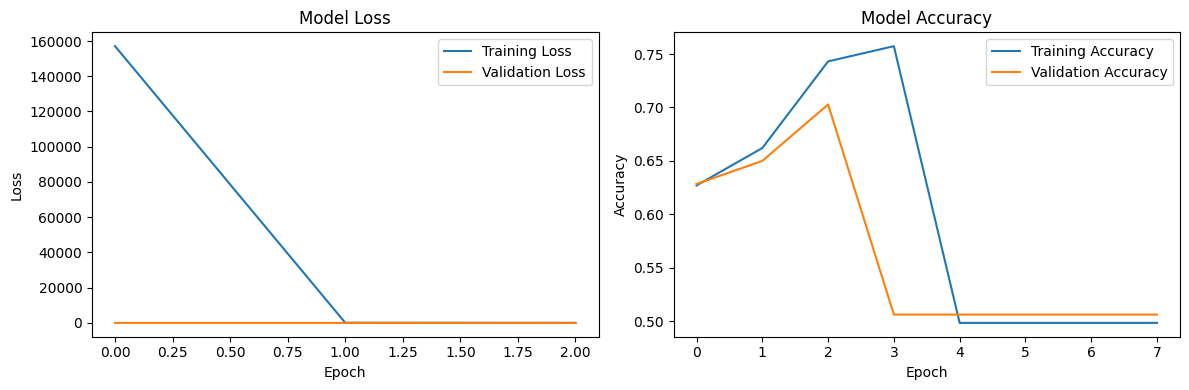

In [25]:
# Analyze training history
import matplotlib.pyplot as plt

print("Epoch-wise metrics:")
print(f"{'Epoch':<6} {'Loss':<10} {'Accuracy':<12} {'Val_Loss':<10} {'Val_Accuracy':<12}")
for i, (loss, acc, val_loss, val_acc) in enumerate(zip(history.history['loss'], history.history['accuracy'], 
                                                         history.history['val_loss'], history.history['val_accuracy']), 1):
    print(f"{i:<6} {loss:<10.4f} {acc:<12.4f} {val_loss:<10.4f} {val_acc:<12.4f}")

# Plot training history
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.tight_layout()
plt.show()